<a href="https://colab.research.google.com/github/lakshmigojanece/Driver-Drowsiness-Detection-using-Eye-Closure-and-Yawning-Analysis-with-Deep-Learning./blob/main/Driver_Drowsiness_Detection_using_Eye_Closure_and_Yawning_Analysis_with_Deep_Learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Project Title:🧠 Driver Drowsiness Detection using Eye Closure and Yawning Analysis with Deep Learning.



Problem Understanding
↓
Dataset Collection
↓
Data Preprocessing
↓
EDA
↓
Model Selection
↓
Model Training
↓
Model Evaluation
↓
Fatigue Decision Logic
↓
Fatigue Progression Analysis
↓
Results & Visualization

In [ ]:
#Step 1 — Import Libraries
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

In [ ]:
#step 2 upload your dataset
from google.colab import files
uploaded = files.upload()  # this will open a file upload dialog

Saving archive (2) (1).zip to archive (2) (1).zip


In [ ]:
#Step 3 — Extract ZIP File
import zipfile

for fn in uploaded.keys():
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall("/content/dataset_raw")

In [ ]:
print("extract all sucessfully")

extract all sucessfully


In [ ]:
#Step 3 — Dataset Path


dataset_raw = "/content/dataset_raw/train"
classes = ['Open','Closed','yawn','no_yawn']

In [ ]:
#Step 4 — Create Train / Val / Test Folders
for folder in ['train','val','test']:
    for cls in classes:
        os.makedirs(f"/content/dataset/{folder}/{cls}", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [ ]:
#Step 5 — Split Dataset
for cls in classes:

    cls_path = os.path.join(dataset_raw, cls)
    imgs = os.listdir(cls_path)

    train_imgs, temp_imgs = train_test_split(imgs, test_size=0.2, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    "/content/dataset/train/"+cls+"/"+img)

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    "/content/dataset/val/"+cls+"/"+img)

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    "/content/dataset/test/"+cls+"/"+img)

print("Dataset split completed")

Dataset split completed


In [ ]:
#Step 5 — Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#Step 6 — Load Dataset
train_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    "/content/dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    "/content/dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 2318 images belonging to 4 classes.
Found 290 images belonging to 4 classes.
Found 292 images belonging to 4 classes.


In [ ]:
#Step 7 — CNN Model
cnn_model = Sequential()

cnn_model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(64,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(128,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128,activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(4,activation='softmax'))

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#— Train CNN Model
#history_cnn = cnn_model.fit(
 #   train_data,
  #  epochs=15,
   # validation_data=val_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 49s 570ms/step - accuracy: 0.4904 - loss: 1.0968 - val_accuracy: 0.7724 - val_loss: 0.5251
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 36s 499ms/step - accuracy: 0.7109 - loss: 0.6036 - val_accuracy: 0.7793 - val_loss: 0.4341
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 36s 484ms/step - accuracy: 0.7384 - loss: 0.5173 - val_accuracy: 0.8138 - val_loss: 0.3919
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 498ms/step - accuracy: 0.7550 - loss: 0.4789 - val_accuracy: 0.8207 - val_loss: 0.3596
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 501ms/step - accuracy: 0.7715 - loss: 0.4440 - val_accuracy: 0.8276 - val_loss: 0.3497
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 503ms/step - accuracy: 0.7707 - loss: 0.4428 - val_accuracy: 0.8310 - val_loss: 0.3251
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 505ms/step - accuracy: 0.7820 - loss: 0.4152 - val_accuracy: 0.8207 - val_loss: 0.3307
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 503ms/step - accuracy: 0.7893 - loss: 0.3827 - val_accu

In [ ]:
#— Train CNN Model
#history_cnn = cnn_model.fit(
 #   train_data,
  #  epochs=12,
   # validation_data=val_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.4240 - loss: 1.1343 - val_accuracy: 0.7828 - val_loss: 0.5259
Epoch 2/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 326s 4s/step - accuracy: 0.6838 - loss: 0.6431 - val_accuracy: 0.8034 - val_loss: 0.4285
Epoch 3/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 307s 4s/step - accuracy: 0.7323 - loss: 0.5370 - val_accuracy: 0.7931 - val_loss: 0.4185
Epoch 4/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.7723 - loss: 0.4618 - val_accuracy: 0.7897 - val_loss: 0.4194
Epoch 5/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 306s 4s/step - accuracy: 0.7884 - loss: 0.4373 - val_accuracy: 0.8069 - val_loss: 0.3560
Epoch 6/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 317s 4s/step - accuracy: 0.7786 - loss: 0.4354 - val_accuracy: 0.8034 - val_loss: 0.3573
Epoch 7/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 306s 4s/step - accuracy: 0.7887 - loss: 0.4230 - val_accuracy: 0.8172 - val_loss: 0.3944
Epoch 8/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.7765 - loss: 0.4315 - val_accuracy: 0.8310 - v

In [ ]:
#— Train CNN Model
history_cnn = cnn_model.fit(
    train_data,
    epochs=17,
    validation_data=val_data)

Epoch 1/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 284s 4s/step - accuracy: 0.8365 - loss: 0.3268 - val_accuracy: 0.7966 - val_loss: 0.3249
Epoch 2/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.8339 - loss: 0.3232 - val_accuracy: 0.8069 - val_loss: 0.3424
Epoch 3/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.8309 - loss: 0.3259 - val_accuracy: 0.8241 - val_loss: 0.3172
Epoch 4/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 0.8279 - loss: 0.3203 - val_accuracy: 0.8069 - val_loss: 0.3267
Epoch 5/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.8244 - loss: 0.3231 - val_accuracy: 0.8172 - val_loss: 0.3173
Epoch 6/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.8339 - loss: 0.3060 - val_accuracy: 0.8172 - val_loss: 0.3141
Epoch 7/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.8218 - loss: 0.3208 - val_accuracy: 0.8379 - val_loss: 0.3156
Epoch 8/17
73/73 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.8382 - loss: 0.3034 - val_accuracy: 0.8310 - v

In [ ]:
#— Train CNN Model
#history_cnn = cnn_model.fit(
 #   train_data,
  #  epochs=20,
   # validation_data=val_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.4643 - loss: 1.0749 - val_accuracy: 0.7552 - val_loss: 0.5147
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.6822 - loss: 0.6384 - val_accuracy: 0.7966 - val_loss: 0.4457
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.7527 - loss: 0.5205 - val_accuracy: 0.8172 - val_loss: 0.4210
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.7592 - loss: 0.4782 - val_accuracy: 0.8138 - val_loss: 0.3977
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7763 - loss: 0.4547 - val_accuracy: 0.8172 - val_loss: 0.3855
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7875 - loss: 0.4312 - val_accuracy: 0.8172 - val_loss: 0.3951
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7814 - loss: 0.4265 - val_accuracy: 0.7793 - val_loss: 0.4089
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.7942 - loss: 0.3867 - val_accuracy: 0.8034 - v

In [ ]:
cnn_model.evaluate(test_data)

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 754ms/step - accuracy: 0.8014 - loss: 0.4233


[0.42334991693496704, 0.801369845867157]

In [ ]:
#Step 9 — MobileNetV2 Transfer Learning
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

In [ ]:
#Step 10 — Add Classification Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(4,activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#Train MobileNetV2
history_mobilenet = mobilenet_model.fit(
    train_data,
    epochs=25,
    validation_data=val_data
)

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.5764 - loss: 0.9803 - val_accuracy: 0.7897 - val_loss: 0.4564
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7593 - loss: 0.4987 - val_accuracy: 0.8069 - val_loss: 0.3742
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7977 - loss: 0.4072 - val_accuracy: 0.8138 - val_loss: 0.3529
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8033 - loss: 0.3748 - val_accuracy: 0.8207 - val_loss: 0.3276
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8223 - loss: 0.3456 - val_accuracy: 0.8207 - val_loss: 0.3147
Epoch 6/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8318 - loss: 0.3343 - val_accuracy: 0.8207 - val_loss: 0.3106
Epoch 7/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8421 - loss: 0.3198 - val_accuracy: 0.8207 - val_loss: 0.3044
Epoch 8/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8430 - loss: 0.3045 - val_accuracy: 0.8207 - v

In [ ]:
#Step 13 — Evaluate MobileNetV2 Model
mobilenet_model.evaluate(test_data)

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8664 - loss: 0.2913


[0.2912810146808624, 0.8664383292198181]

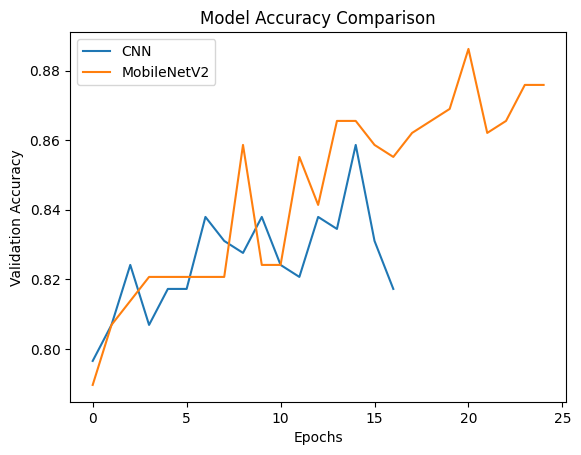

In [ ]:
#Step 17 — Accuracy Comparison Graph
plt.plot(history_cnn.history['val_accuracy'], label="CNN")

plt.plot(history_mobilenet.history['val_accuracy'], label="MobileNetV2")

plt.title("Model Accuracy Comparison")

plt.xlabel("Epochs")

plt.ylabel("Validation Accuracy")

plt.legend()

plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


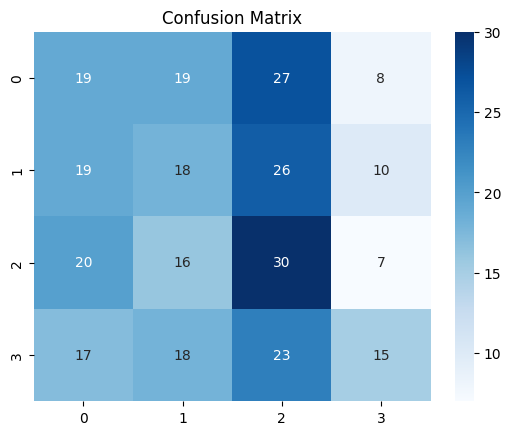

In [ ]:
#Step 18 — Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

pred = mobilenet_model.predict(test_data)

y_pred = np.argmax(pred, axis=1)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

In [ ]:
#Step 19 — Classification Report
print(classification_report(y_true,y_pred))


              precision    recall  f1-score   support

           0       0.25      0.26      0.26        73
           1       0.25      0.25      0.25        73
           2       0.28      0.41      0.34        73
           3       0.38      0.21      0.27        73

    accuracy                           0.28       292
   macro avg       0.29      0.28      0.28       292
weighted avg       0.29      0.28      0.28       292



In [ ]:
#Step 20 — Future Prediction (Upload Image)
from google.colab import files

uploaded = files.upload()

Saving ChatGPT_Image_Mar_13_2026_12_29_04_PM.png to ChatGPT_Image_Mar_13_2026_12_29_04_PM.png


In [ ]:
#Step 21 — Predict Image
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path,target_size=(224,224))

img_array = image.img_to_array(img)/255

img_array = np.expand_dims(img_array,axis=0)

pred = mobilenet_model.predict(img_array)

classes = ['Open','Closed','yawn','no_yawn']

pred_class = classes[np.argmax(pred)]

print("Prediction :",pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction : no_yawn


In [ ]:
#Step 22 — Fatigue Decision Logic

def fatigue_level(pred_class):

    if pred_class == 'Closed':
        return "Severe Fatigue"

    elif pred_class == 'yawn':
        return "Mild Fatigue"

    else:
        return "Alert"


stage = fatigue_level(pred_class)

print("Prediction:", pred_class)
print("Driver Fatigue Level:", stage)

Prediction: no_yawn
Driver Fatigue Level: Alert


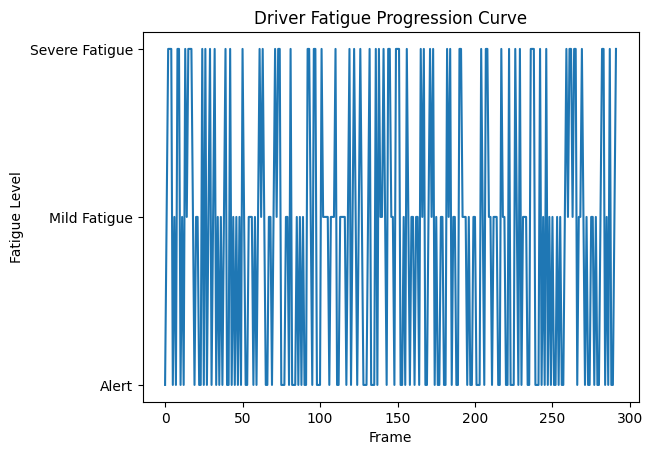

In [ ]:
#Step 23 — Fatigue Progression Curve

fatigue_values = []

for p in y_pred:

    cls = classes[p]

    if cls in ['Open','no_yawn']:
        fatigue_values.append(0)

    elif cls == 'yawn':
        fatigue_values.append(1)

    else:
        fatigue_values.append(2)

plt.plot(fatigue_values)

plt.title("Driver Fatigue Progression Curve")

plt.xlabel("Frame")

plt.ylabel("Fatigue Level")

plt.yticks([0,1,2],["Alert","Mild Fatigue","Severe Fatigue"])

plt.show()

In [ ]:
mobilenet_model.save("drowsiness_model.keras")  # Make sure you have .keras extension

In [ ]:
from google.colab import files

files.download("drowsiness_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(train_data.classes)

[0 0 0 ... 3 3 3]


In [ ]:
print(train_data.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [ ]:
print(train_data.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [ ]:
# Save MobileNetV2 model as .h5 for Streamlit
mobilenet_model.save("drowsiness_model.h5")

In [ ]:
from google.colab import files
files.download("drowsiness_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

dataset = "/content/dataset/train"

for cls in ['Open','Closed','yawn','no_yawn']:
    path = os.path.join(dataset, cls)
    print(cls, ":", len(os.listdir(path)))

Open : 580
Closed : 580
yawn : 578
no_yawn : 580


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0
